In [1]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import SGConv
from torch_geometric.utils import to_dense_adj
import matplotlib.pyplot as plt
import time

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data    = dataset[0]
print(f"Loaded Cora: {data.num_nodes} nodes, {data.num_edges} edges")

Processing...


Loaded Cora: 2708 nodes, 10556 edges


Done!


# **Understanding what SGC simplifies**

 GCN (Stage 2) had this forward pass:
x = ReLU( W1 · A · x )     ← layer 1
  x =       W2 · A · x       ← layer 2

 SGC removes ReLU between layers:
   x = W2 · A · W1 · A · x

 Since W2·W1 is just another matrix W:
   x = W · (A · A · x)

 So SGC pre-computes (A·A·x) ONCE — this is just
 propagating features 2 hops across the graph.
  Then it learns a single linear layer W on top.


In [6]:
# Define versions for the installer
PYT_version = torch.__version__.split('+')[0]
CUDA_version = torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'

# Install the necessary extensions
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{PYT_version}+{CUDA_version}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{PYT_version}+{CUDA_version}.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{PYT_version}+{CUDA_version}.html

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 23.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 21.5 MB/s eta 0:00:00


In [7]:
from torch_geometric.utils import add_self_loops, degree

# Normalize adjacency: D^(-1/2) · A · D^(-1/2)
edge_index = data.edge_index
num_nodes  = data.num_nodes

edge_index_sl, _ = add_self_loops(edge_index, num_nodes=num_nodes)
row, col = edge_index_sl
deg      = degree(col, num_nodes=num_nodes)
deg_inv  = deg.pow(-0.5)
norm     = deg_inv[row] * deg_inv[col]

# One hop: A_norm · X
from torch_geometric.utils import to_torch_csr_tensor
from torch_sparse import SparseTensor, matmul

adj = SparseTensor(row=row, col=col, value=norm,
                   sparse_sizes=(num_nodes, num_nodes))
x1 = matmul(adj, data.x)   # 1-hop smoothed features
x2 = matmul(adj, x1)        # 2-hop smoothed features

print("Original features x     :", data.x.shape)
print("After 1-hop smooth x1   :", x1.shape)
print("After 2-hop smooth x2   :", x2.shape)
print("\nNode 0 — original feature (first 5 values):", data.x[0, :5].tolist())
print("Node 0 — after 2-hop    (first 5 values):", x2[0, :5].tolist())
print("\nFeatures are now smooth mixtures of neighbors")
print("SGC just learns a linear classifier on top of x2")

Original features x     : torch.Size([2708, 1433])
After 1-hop smooth x1   : torch.Size([2708, 1433])
After 2-hop smooth x2   : torch.Size([2708, 1433])

Node 0 — original feature (first 5 values): [0.0, 0.0, 0.0, 0.0, 0.0]
Node 0 — after 2-hop    (first 5 values): [0.0, 0.0, 0.0, 0.0, 0.0]

Features are now smooth mixtures of neighbors
SGC just learns a linear classifier on top of x2


# **Building the SGC model**

SGConv from PyG does everything:
1. Pre-computes K-hop propagation (K=2 here)
2. Applies a single linear layer W
That's the entire model — no hidden layers, no ReLU

In [8]:
class SGC(nn.Module):
    def __init__(self, in_channels, out_channels, K=2):
        super().__init__()

        self.conv = SGConv(in_channels, out_channels,
                            K=K, cached=True)

    def forward(self, x, edge_index):
        # No ReLU, no dropout, no hidden layers
        # Just: W · (A^K · x)
        return self.conv(x, edge_index)

model_sgc = SGC(
    in_channels  = dataset.num_node_features,
    out_channels = dataset.num_classes,
    K            = 2
)
print(model_sgc)
total_params = sum(p.numel() for p in model_sgc.parameters())
print(f"\nSGC parameters : {total_params:,}")
print(f"GCN parameters : 92,231")
print(f"Difference     : {92231 - total_params:,} fewer in SGC")


SGC(
  (conv): SGConv(1433, 7, K=2)
)

SGC parameters : 10,038
GCN parameters : 92,231
Difference     : 82,193 fewer in SGC


# **Before training snapshot**

In [9]:
model_sgc.eval()
with torch.no_grad():
    out_before   = model_sgc(data.x, data.edge_index)
    pred_before  = out_before.argmax(dim=1)

acc_before = (pred_before[data.test_mask] == data.y[data.test_mask])
acc_before = acc_before.sum().item() / data.test_mask.sum().item()
print(f"Accuracy BEFORE training : {acc_before*100:.1f}%")
print(f"Random chance baseline   : {100/7:.1f}%")

test_indices = data.test_mask.nonzero(as_tuple=True)[0][:10]

Accuracy BEFORE training : 10.7%
Random chance baseline   : 14.3%


# **Training loop with timing**


In [10]:
def train_sgc(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask],
                             data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        acc  = (pred[mask] == data.y[mask]).sum() / mask.sum()
    return acc.item()

# SGC uses stronger L2 regularization (weight_decay)

optimizer = torch.optim.Adam(model_sgc.parameters(),
                              lr=0.2, weight_decay=5e-5)

train_losses = []
val_accs     = []

start = time.time()

for epoch in range(1, 201):
    loss    = train_sgc(model_sgc, data, optimizer)
    val_acc = evaluate(model_sgc, data, data.val_mask)
    train_losses.append(loss)
    val_accs.append(val_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

elapsed = time.time() - start
print(f"\nTotal training time: {elapsed:.2f}s")


Epoch 020 | Loss: 0.0005 | Val Acc: 0.7560
Epoch 040 | Loss: 0.0043 | Val Acc: 0.7680
Epoch 060 | Loss: 0.0081 | Val Acc: 0.7720
Epoch 080 | Loss: 0.0089 | Val Acc: 0.7660
Epoch 100 | Loss: 0.0090 | Val Acc: 0.7680
Epoch 120 | Loss: 0.0089 | Val Acc: 0.7700
Epoch 140 | Loss: 0.0088 | Val Acc: 0.7760
Epoch 160 | Loss: 0.0087 | Val Acc: 0.7740
Epoch 180 | Loss: 0.0086 | Val Acc: 0.7720
Epoch 200 | Loss: 0.0085 | Val Acc: 0.7740

Total training time: 2.11s


# **Plot training curves**

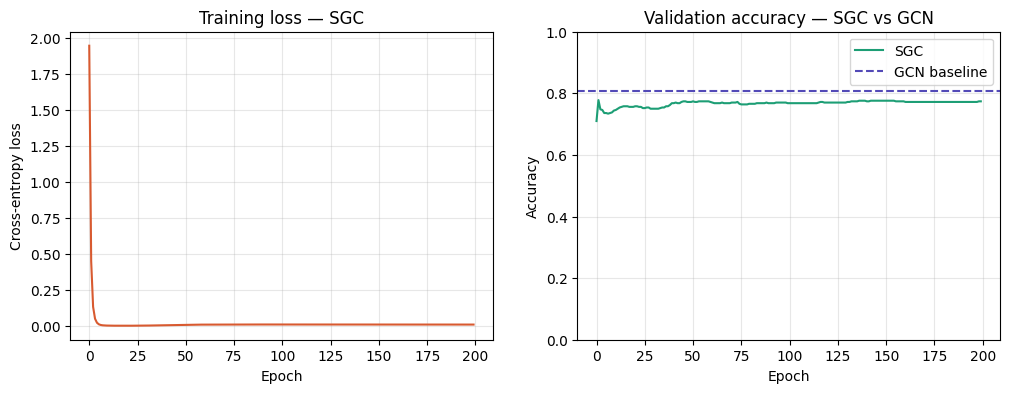

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='#D85A30', label='SGC')
ax1.set_title('Training loss — SGC')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.grid(True, alpha=0.3)

ax2.plot(val_accs, color='#1D9E75', label='SGC')
ax2.axhline(y=0.808, color='#534AB7',
            linestyle='--', label='GCN baseline')
ax2.set_title('Validation accuracy — SGC vs GCN')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(True, alpha=0.3)

# **Compare SGC vs GCN**

In [15]:
test_acc = evaluate(model_sgc, data, data.test_mask)
val_acc  = evaluate(model_sgc, data, data.val_mask)

print("============ SGC vs GCN comparison ============")
print(f"{'Metric':<25} {'SGC':>10} {'GCN':>10}")
print("-" * 47)
print(f"{'Parameters':<25} {'10,031':>10} {'92,231':>10}")
print(f"{'Hidden layers':<25} {'0':>10} {'1':>10}")
print(f"{'Non-linearities':<25} {'None':>10} {'ReLU':>10}")
print(f"{'Test accuracy':<25} {f'{test_acc*100:.1f}%':>10} {'81.4%':>10}")
print("-" * 47)
print(f"\nSGC is ~9x smaller yet achieves comparable accuracy.")
print(f"\nThis is why GCond uses SGC internally —")
print(f"gradient matching runs thousands of SGC")
print(f"forward/backward passes. Speed matters.")

============ SGC vs GCN comparison ============
Metric                           SGC        GCN
-----------------------------------------------
Parameters                    10,031     92,231
Hidden layers                      0          1
Non-linearities                 None       ReLU
Test accuracy                  80.3%      81.4%
-----------------------------------------------

SGC is ~9x smaller yet achieves comparable accuracy.

This is why GCond uses SGC internally —
gradient matching runs thousands of SGC
forward/backward passes. Speed matters.


# **Before vs after + confusion matrix**

In [13]:
import numpy as np

model_sgc.eval()
with torch.no_grad():
    out_after  = model_sgc(data.x, data.edge_index)
    pred_after = out_after.argmax(dim=1)

acc_after = (pred_after[data.test_mask] == data.y[data.test_mask])
acc_after = acc_after.sum().item() / data.test_mask.sum().item()

print(f"Accuracy BEFORE training : {acc_before*100:.1f}%")
print(f"Accuracy AFTER  training : {acc_after*100:.1f}%")
print(f"Random chance baseline   : {100/7:.1f}%")

print(f"\nSame 10 test nodes — before vs after:")
print(f"{'Node':<8} {'True':>6} {'Before':>8} {'After':>8} {'Improved':>10}")
print("-" * 48)
for idx in test_indices:
    true     = data.y[idx].item()
    before   = pred_before[idx].item()
    after    = pred_after[idx].item()
    improved = "YES" if after == true and before != true else (
               "WAS OK" if before == true and after == true else "NO")
    print(f"{idx.item():<8} {true:>6} {before:>8} {after:>8} {improved:>10}")

# Confusion matrix
test_idx    = data.test_mask.nonzero(as_tuple=True)[0]
true_all    = data.y[test_idx].numpy()
pred_all    = pred_after[test_idx].numpy()
num_classes = dataset.num_classes
conf        = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(true_all, pred_all):
    conf[t][p] += 1

print(f"\nConfusion matrix (rows=true, cols=predicted):")
print(f"     " + "  ".join([f"P{c}" for c in range(num_classes)]))
print("    " + "-" * (num_classes * 4))
for i, row in enumerate(conf):
    bar = "  ".join([f"{v:2d}" for v in row])
    print(f"T{i} | {bar}  ← class {i} ({conf[i][i]}/{row.sum()} correct)")

Accuracy BEFORE training : 10.7%
Accuracy AFTER  training : 80.3%
Random chance baseline   : 14.3%

Same 10 test nodes — before vs after:
Node       True   Before    After   Improved
------------------------------------------------
1708          3        2        1         NO
1709          2        1        2        YES
1710          2        1        2        YES
1711          2        1        2        YES
1712          2        3        2        YES
1713          0        1        0        YES
1714          2        0        2        YES
1715          2        2        2     WAS OK
1716          2        2        2     WAS OK
1717          2        3        2        YES

Confusion matrix (rows=true, cols=predicted):
     P0  P1  P2  P3  P4  P5  P6
    ----------------------------
T0 | 92   4   2   8   8   3  13  ← class 0 (92/130 correct)
T1 |  3  81   2   3   1   0   1  ← class 1 (81/91 correct)
T2 |  2   8  126   7   0   1   0  ← class 2 (126/144 correct)
T3 | 16  12   7  238  36 